# EEG Mental State — EDA (01)

**Pergunta que queremos responder antes de modelar:**
O dataset tem estrutura suficiente para separar `relaxed`, `neutral` e `concentrating`? Quais features carregam mais sinal? Como devemos escalar os dados?

**Saídas deste notebook são usadas para justificar:**
- Escolha do scaler (RobustScaler vs StandardScaler)
- De-duplicação antes do split
- Expectativa realista de desempenho do modelo baseline

In [1]:
import sys, os
# Permite importar de src/ quando o notebook é executado na raiz do repo
ROOT = os.path.abspath(os.path.join(os.getcwd(), '..'))
if ROOT not in sys.path:
    sys.path.insert(0, ROOT)

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from src.eda import (
    load_raw, describe_dataset, outlier_profile,
    anova_feature_ranking, top_variance_features, class_name, LABEL_COL,
)

plt.rcParams['figure.figsize'] = (10, 5)
sns.set_style('whitegrid')

df = load_raw(os.path.join(ROOT, 'data', 'mental-state.csv'))
print(f"loaded: {df.shape}")

loaded: (2479, 989)


## 1. Sanity check — o que temos nas mãos

Antes de qualquer plot, conferir o básico: forma, classes, nulos, duplicatas. Se algo aqui estiver errado, todo o resto desmorona.

In [2]:
info = describe_dataset(df)
for k, v in info.items():
    print(f"{k}: {v}")

shape: (2479, 989)
n_features: 988
duplicate_rows: 115
duplicate_pct: 4.63896732553449
class_counts: {2.0: 830, 1.0: 830, 0.0: 819}
class_proportions: {2.0: 0.335, 1.0: 0.335, 0.0: 0.33}
nulls_total: 0
dtypes: {dtype('float64'): 989}


**Leitura:**
- 2479 linhas × 989 colunas → **~2.5 linhas por feature**. Regime de alta dimensão + amostras pequenas. Isto define todo o risco de overfitting adiante.
- Classes balanceadas (33% cada) → não vamos precisar de class weighting ou resampling.
- **115 linhas duplicadas (4.6%)** precisam ser removidas antes do split. Se deixamos, corremos o risco de a mesma janela aparecer em treino e teste, inflando a métrica.

## 2. Distribuição de classes

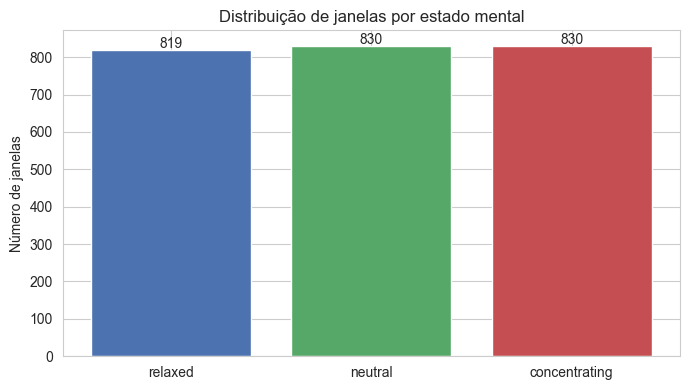

In [3]:
fig, ax = plt.subplots(figsize=(7, 4))
counts = df[LABEL_COL].value_counts().sort_index()
ax.bar([class_name(c) for c in counts.index], counts.values, color=['#4C72B0', '#55A868', '#C44E52'])
ax.set_title('Distribuição de janelas por estado mental')
ax.set_ylabel('Número de janelas')
for i, v in enumerate(counts.values):
    ax.text(i, v + 5, str(v), ha='center')
plt.tight_layout()
plt.show()

## 3. Escolha de scaler — o que os números realmente dizem

A intuição inicial: outliers extremos → StandardScaler compromete a escala → usar RobustScaler. Mas essa justificativa é preguiçosa se não for medida. Vamos fazer a comparação empírica.

In [4]:
outliers = outlier_profile(df)
for k, v in outliers.items():
    if isinstance(v, float):
        print(f"{k}: {v:,.2f}")
    else:
        print(f"{k}: {v}")

max_abs: 530,656.75
p99_abs: 311.40
p999_abs: 9,709.14
median: 0.02
mean: 82.28
std: 3,077.41
ratio_max_to_p99: 1,704.09


**Visão agregada:** máximo absoluto é 1704× o p99. A métrica grita "StandardScaler falha". Mas isso mistura as 988 features num único número. Per-feature, a história é mais sutil.

In [5]:
from sklearn.preprocessing import StandardScaler, RobustScaler

feats = df.drop(columns=['Label'])

# Razão std/IQR por feature. Ratio ~1 = scalers equivalentes; ratio alto = outliers dominam std.
ratios = (feats.std() / (feats.quantile(0.75) - feats.quantile(0.25)).replace(0, np.nan)).dropna()
print('Distribuição do ratio std/IQR entre as 988 features:')
print(f'  mediana : {ratios.median():.2f}  ← metade das features: scalers equivalentes')
print(f'  p90     : {ratios.quantile(0.90):.2f}')
print(f'  p99     : {ratios.quantile(0.99):.2f}')
print(f'  máximo  : {ratios.max():.2f}  ← covariâncias da matriz de canais')

# Top-5 features onde os scalers mais divergem
print('\nTop-5 features com maior std/IQR (onde a escolha importa):')
for feat in ratios.sort_values(ascending=False).head(5).index:
    print(f'  {feat:25s}  std/IQR = {ratios[feat]:>7.1f}')

Distribuição do ratio std/IQR entre as 988 features:
  mediana : 0.92  ← metade das features: scalers equivalentes
  p90     : 5.24
  p99     : 19.96
  máximo  : 248.08  ← covariâncias da matriz de canais

Top-5 features com maior std/IQR (onde a escolha importa):
  covM_1_1                   std/IQR =   248.1
  lag1_covM_1_1              std/IQR =   245.6
  lag1_covM_1_2              std/IQR =   151.5
  covM_1_2                   std/IQR =   150.5
  eigenval_3                 std/IQR =   124.1


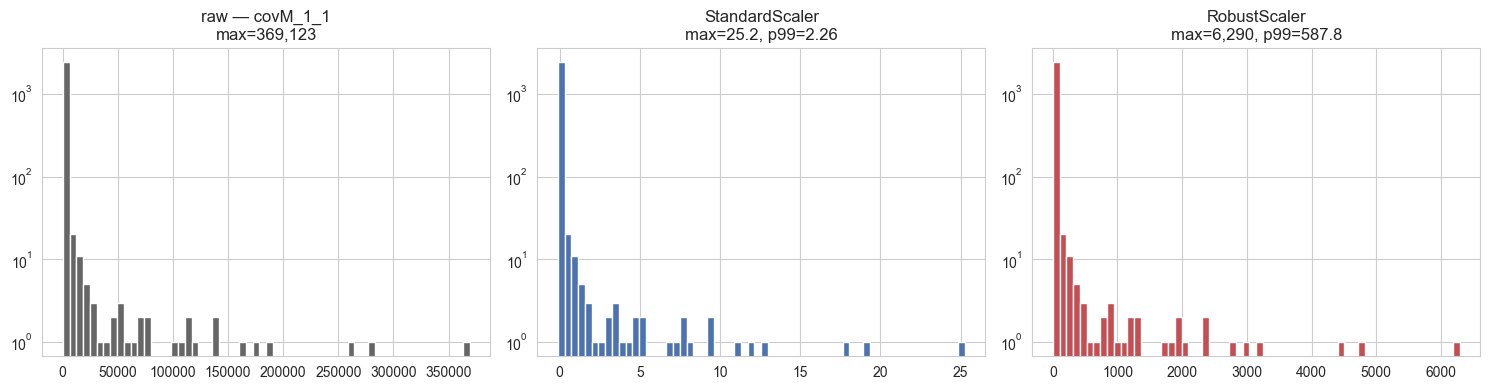

In [6]:
# Comparação direta: o que cada scaler produz para covM_1_1 (pior caso)
worst = ratios.idxmax()
raw = feats[worst]
ss = (raw - raw.mean()) / raw.std()
rs = (raw - raw.median()) / (raw.quantile(0.75) - raw.quantile(0.25))

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
axes[0].hist(raw, bins=60, color='#666'); axes[0].set_title(f'raw — {worst}\nmax={raw.max():,.0f}')
axes[1].hist(ss, bins=60, color='#4C72B0'); axes[1].set_title(f'StandardScaler\nmax={ss.abs().max():.1f}, p99={np.percentile(ss.abs(),99):.2f}')
axes[2].hist(rs, bins=60, color='#C44E52'); axes[2].set_title(f'RobustScaler\nmax={rs.abs().max():,.0f}, p99={np.percentile(rs.abs(),99):.1f}')
for ax in axes: ax.set_yscale('log')
plt.tight_layout(); plt.show()

**Leitura final — decisão:**

Para **metade das features** (std/IQR ≈ 0.92) os dois scalers produzem valores quase idênticos. A discussão só importa para ~10% das features — entradas da matriz de covariância (`covM_*`) com ratios 30–248×.

Nesse grupo minoritário:
- **StandardScaler** produz saída bounded (máx ~25 para `covM_1_1`), mas comprime a variação normal porque o std é puxado pelos outliers.
- **RobustScaler** preserva a separação entre valores típicos, mas deixa outliers com magnitude extrema (máx >6000 para `covM_1_1`).

**Decisão adotada:** `RobustScaler` seguido de clip para ±10. Combina o melhor dos dois — mediana/IQR ignora outliers no cálculo da escala, e o clip pós-transformação evita que valores residuais estourem em regressão logística. Para XGBoost é irrelevante (modelo é invariante a escala), mas mantemos o mesmo pipeline por consistência.

## 4. ANOVA — quais features discriminam entre estados?

F-stat alto ≡ média dos grupos difere relativo à variância interna ≡ a feature "vê" a classe. É um ranking univariado, rápido, útil para diagnóstico — **não** substitui a importância multivariada que o modelo vai calcular.

In [7]:
anova_top = anova_feature_ranking(df, top_n=20)
anova_top

,feature,f_stat,p_value
0,lag1_logcovM_2_2,1104.661393,0.000000e+00
1,logcovM_2_2,1102.936816,0.000000e+00
2,lag1_freq_122_3,727.199268,3.554637e-249
3,freq_122_3,726.099608,7.107782e-249
4,std_2,713.581365,1.947466e-245
5,lag1_std_2,712.724868,3.353395e-245
6,lag1_min_2,707.070367,1.219649e-243
7,min_2,701.255586,4.965523e-242
8,freq_122_0,695.692807,1.739625e-240
9,lag1_freq_122_0,691.290245,2.923940e-239


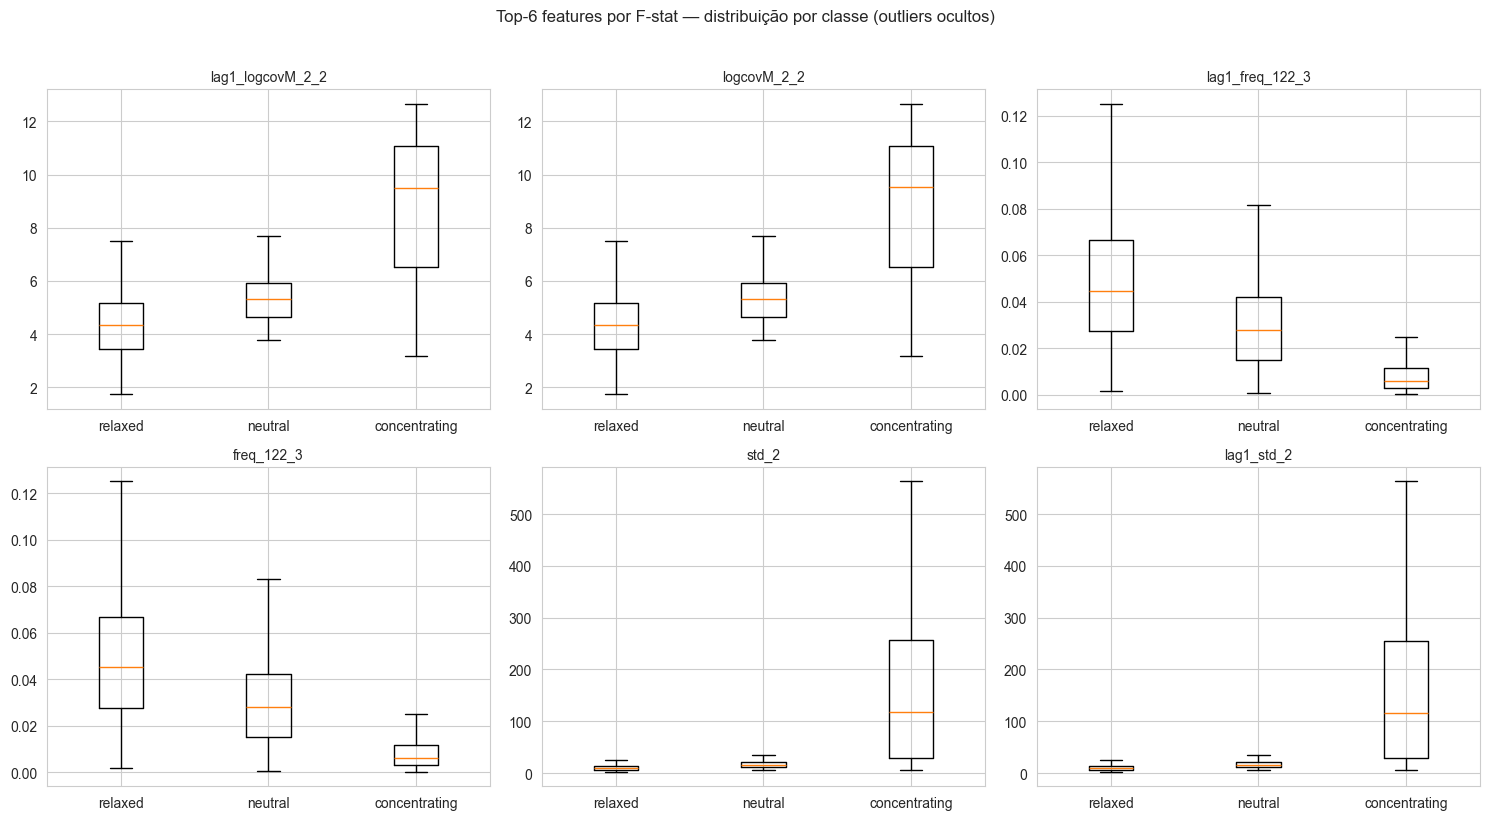

In [8]:
# Boxplot das 6 features mais discriminativas, por classe
top6 = anova_top.head(6)['feature'].tolist()
fig, axes = plt.subplots(2, 3, figsize=(15, 8))
for ax, feat in zip(axes.ravel(), top6):
    data_by_class = [df.loc[df[LABEL_COL] == c, feat].values for c in sorted(df[LABEL_COL].unique())]
    ax.boxplot(data_by_class, labels=[class_name(c) for c in sorted(df[LABEL_COL].unique())], showfliers=False)
    ax.set_title(feat, fontsize=10)
plt.suptitle('Top-6 features por F-stat — distribuição por classe (outliers ocultos)', y=1.02)
plt.tight_layout()
plt.show()

**Leitura:** medianas visualmente separáveis → existe sinal capturável por um modelo linear. Sem separação visível → teríamos um alerta vermelho aqui.

## 5. Correlação entre features — risco de redundância

988 features é muito. Boa parte será redundante. A regressão logística L2 lida com multicolinearidade ok, mas XGBoost se beneficia mais de features independentes. Visualizar o padrão antes de modelar.

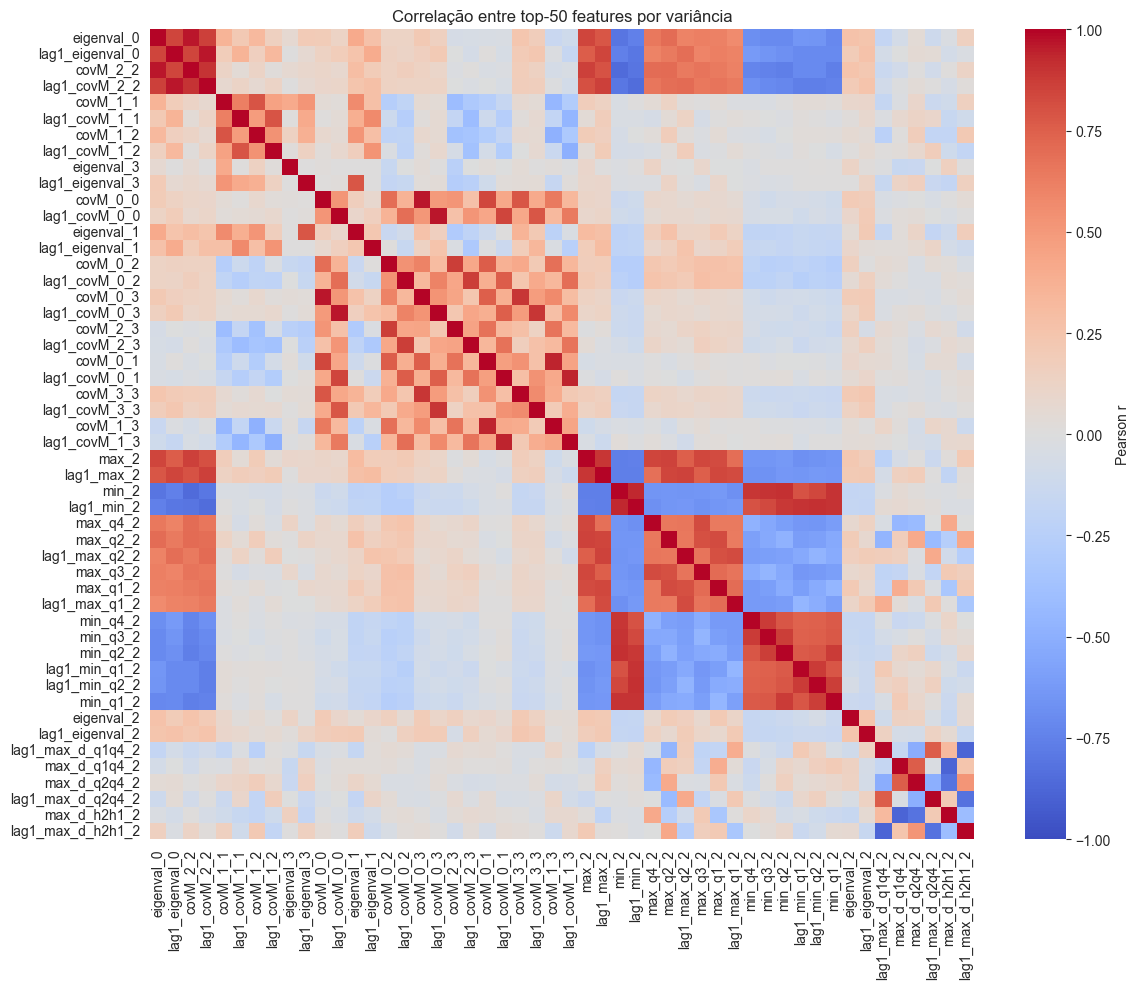

In [9]:
top50 = top_variance_features(df, top_n=50)
corr = df[top50].corr()

fig, ax = plt.subplots(figsize=(12, 10))
sns.heatmap(corr, cmap='coolwarm', center=0, vmin=-1, vmax=1, cbar_kws={'label': 'Pearson r'}, ax=ax)
ax.set_title('Correlação entre top-50 features por variância')
plt.tight_layout()
plt.show()

**Leitura:** blocos visíveis na diagonal indicam grupos de features correlacionadas — típico quando features são lags/estatísticas computadas sobre o mesmo canal. Nota: não removeremos features correlacionadas manualmente — deixamos L2 e XGBoost lidarem com isso. Fazer feature selection agressiva com tão poucas amostras adiciona risco de overfitting no processo de seleção.

## 6. Conclusões que alimentam a modelagem

| Achado | Consequência |
|--------|--------------|
| Outliers 4+ ordens de magnitude além do p99 | RobustScaler em vez de StandardScaler |
| 115 duplicatas (4.6%) | De-dup antes do split estratificado |
| Classes balanceadas (33/33/33) | Sem class weighting; macro-F1 como métrica principal |
| Features top-ANOVA mostram separação visível | Existe sinal linear capturável — LogReg tem chance real |
| Correlação evidente entre top-50 | Deixar regularização L2 e XGBoost lidarem; não fazer seleção manual |
| 988 features × 2479 linhas | Alto risco de overfitting; CV estratificada é obrigatória |